# EDA: 'Equity' in Public Health Discourse
**IDS 570 — Term Project | Step 2: Exploratory Data Analysis**

This notebook covers:
1. Data loading and inspection
2. Frequency analysis of 'equity' by document type
3. Distribution analysis (academic vs. others)
4. Quick insights summary

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings("ignore")
from pathlib import Path

# Plot style
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

print("Libraries loaded.")

Libraries loaded.


## 1. Load and Inspect the Data

In [2]:
DATA_DIR = Path("../01_data")
df = pd.read_csv(DATA_DIR / "equity_contexts.csv")

print(f"Total rows (equity occurrences): {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing values:\n{df.isnull().sum()}")

Total rows (equity occurrences): 6,109
Columns: ['category', 'title', 'source_label', 'url', 'equity_context']
Missing values:
category          0
title             0
source_label      0
url               0
equity_context    0
dtype: int64


In [3]:
df.head(3)

,category,title,source_label,url,equity_context
0,Federal policy / government health policy docu...,Developing Health Equity Measures,ASPE / HHS,https://aspe.hhs.gov/sites/default/files/priva...,C O N T R A C T O R P R O J E C T R E P O R T ...
1,Federal policy / government health policy docu...,Developing Health Equity Measures,ASPE / HHS,https://aspe.hhs.gov/sites/default/files/priva...,"ASPE wrote two Reports to Congress, making rec..."
2,Federal policy / government health policy docu...,Developing Health Equity Measures,ASPE / HHS,https://aspe.hhs.gov/sites/default/files/priva...,This included the recommendations that the Cen...


In [4]:
# Clean up category names — shorten for readability in plots
category_map = {
    "State or local health department reports/documents": "State/Local Health Dept.",
    "Federal policy / government health policy documents": "Federal Policy",
    "NGO / nonprofit health reports/documents": "NGO / Nonprofit",
    "Academic article abstracts": "Academic Abstracts",
    "Mixed / ambiguous framing": "Mixed / Ambiguous",
    "Structural / justice framing": "Structural / Justice",
    "Distribution / access / resource framing": "Distributional / Access",
    "Policy implementation / measurement / systems framing": "Policy / Measurement",
}

df["category_short"] = df["category"].map(category_map).fillna(df["category"])

# Separate the document-type categories from the framing categories
doc_type_cats = [
    "State/Local Health Dept.",
    "Federal Policy",
    "NGO / Nonprofit",
    "Academic Abstracts",
]
framing_cats = [
    "Structural / Justice",
    "Distributional / Access",
    "Policy / Measurement",
    "Mixed / Ambiguous",
]

df_docs = df[df["category_short"].isin(doc_type_cats)].copy()
df_framing = df[df["category_short"].isin(framing_cats)].copy()

print(f"Document-type rows: {len(df_docs):,}")
print(f"Pre-labeled framing rows: {len(df_framing):,}")

Document-type rows: 5,967
Pre-labeled framing rows: 142


## 2. Frequency Analysis by Document Type

In [5]:
# --- 2a. Raw counts by document type ---
cat_counts = df_docs["category_short"].value_counts().reset_index()
cat_counts.columns = ["Document Type", "Equity Occurrences"]

print("Equity occurrences by document type:")
print(cat_counts.to_string(index=False))
print(f"\nTotal: {cat_counts['Equity Occurrences'].sum():,}")

Equity occurrences by document type:
           Document Type  Equity Occurrences
State/Local Health Dept.                3276
          Federal Policy                1224
         NGO / Nonprofit                 944
      Academic Abstracts                 523

Total: 5,967


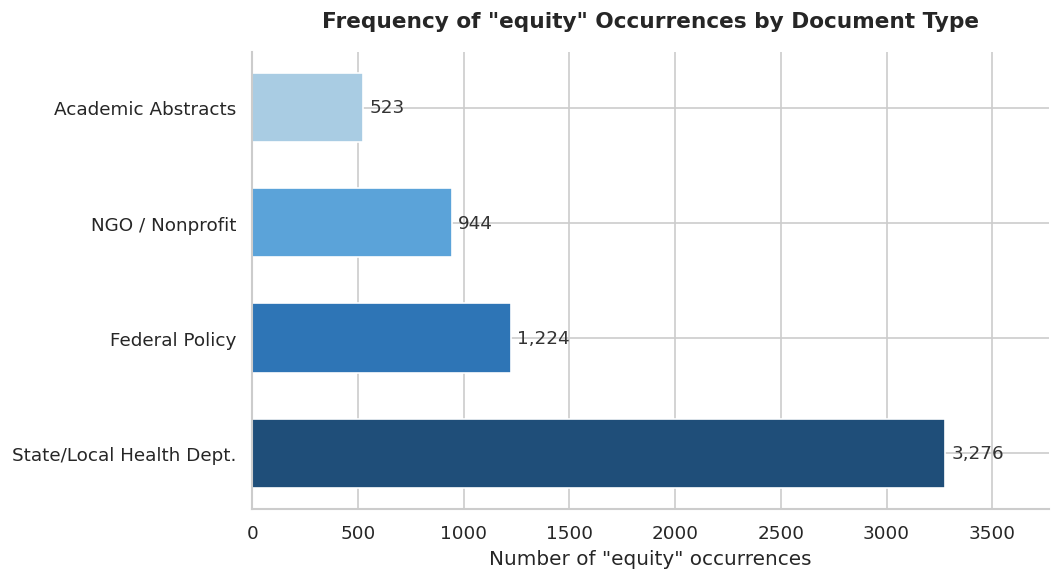

Saved: fig1_frequency_by_doctype.png


In [6]:
# --- 2b. Bar chart: occurrences by document type ---
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#1F4E79", "#2E75B6", "#5BA3D9", "#A9CCE3"]
bars = ax.barh(
    cat_counts["Document Type"],
    cat_counts["Equity Occurrences"],
    color=colors,
    edgecolor="white",
    height=0.6,
)

for bar, val in zip(bars, cat_counts["Equity Occurrences"]):
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=11,
        color="#333333",
    )

ax.set_xlabel('Number of "equity" occurrences', fontsize=12)
ax.set_title(
    'Frequency of "equity" Occurrences by Document Type',
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlim(0, cat_counts["Equity Occurrences"].max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig1_frequency_by_doctype.png", bbox_inches="tight")
plt.show()
print("Saved: fig1_frequency_by_doctype.png")

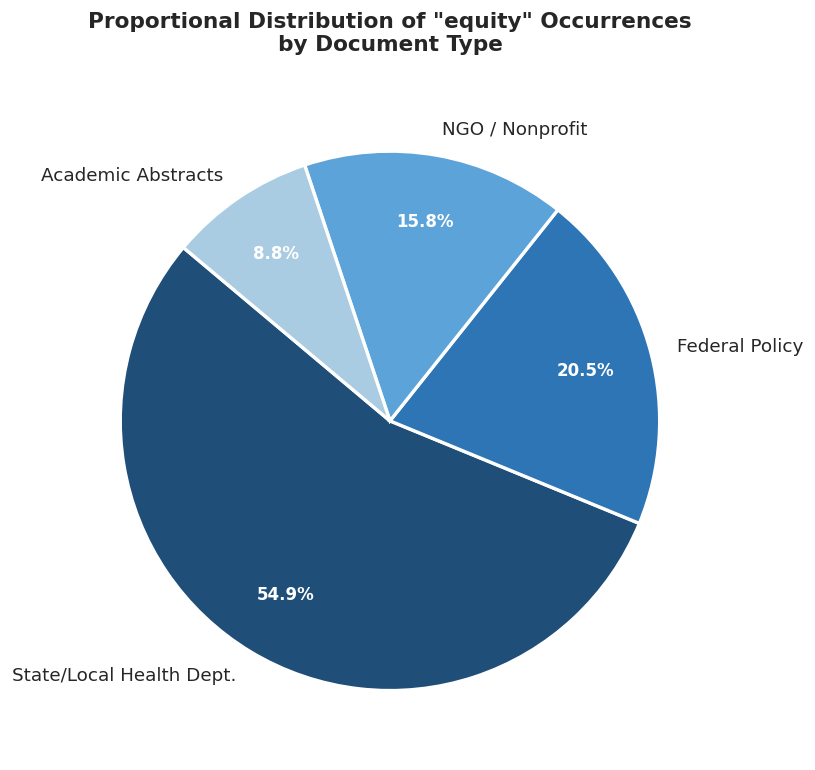

Saved: fig2_proportion_pie.png


In [7]:
# --- 2c. Proportional breakdown (pie) ---
fig, ax = plt.subplots(figsize=(7, 7))

wedge_colors = ["#1F4E79", "#2E75B6", "#5BA3D9", "#A9CCE3"]
wedges, texts, autotexts = ax.pie(
    cat_counts["Equity Occurrences"],
    labels=cat_counts["Document Type"],
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color("white")
    autotext.set_fontweight("bold")

ax.set_title(
    'Proportional Distribution of "equity" Occurrences\nby Document Type',
    fontsize=13,
    fontweight="bold",
    pad=20,
)
plt.tight_layout()
plt.savefig("fig2_proportion_pie.png", bbox_inches="tight")
plt.show()
print("Saved: fig2_proportion_pie.png")

As we can see, 'State/Local Health Department' Document Type has the most number of occurrences of the term 'equity' occuring representing 54.9%. The smallest percentage comes from the academic abstracts. This suggests that that equity language is far more densely embedded in institutional reporting than in scholarly literature, which is consistent with H2 — that non-academic texts deploy equity in operational and programmatic contexts rather than conceptual ones. This raises a methodological concern: any downstream classifier trained on this corpus will be disproportionately exposed to state/local institutional language, which may bias predictions toward distributional rather than structural framings of equity.

## 3. Distribution Analysis: Academic vs. Others

In [8]:
# --- 3a. Create binary academic vs. non-academic label ---
df_docs["is_academic"] = df_docs["category_short"].apply(
    lambda x: "Academic Abstracts" if x == "Academic Abstracts" else "Non-Academic"
)

acad_counts = df_docs["is_academic"].value_counts()
print("Academic vs. Non-Academic breakdown:")
print(acad_counts)
print(
    f"\nAcademic share: {acad_counts['Academic Abstracts'] / acad_counts.sum() * 100:.1f}%"
)

Academic vs. Non-Academic breakdown:
is_academic
Non-Academic          5444
Academic Abstracts     523
Name: count, dtype: int64

Academic share: 8.8%


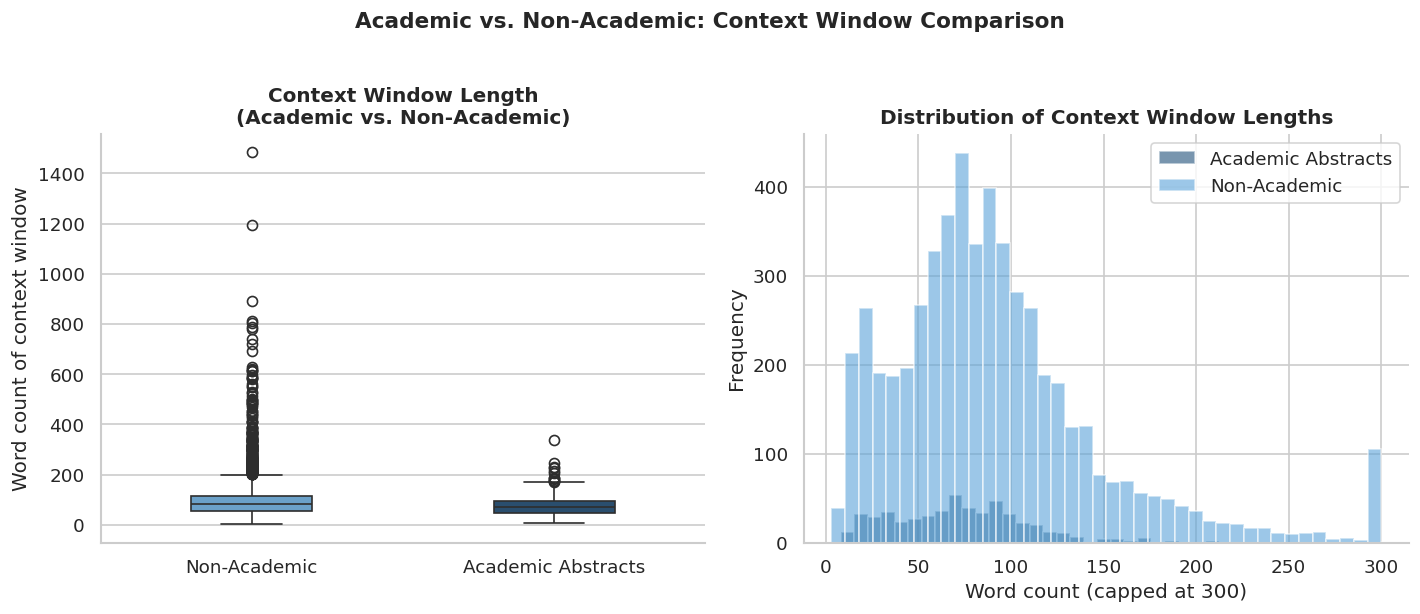

Saved: fig3_academic_vs_nonacademic.png


In [9]:
# --- 3b. Context length comparison: academic vs non-academic ---
df_docs["context_length"] = df_docs["equity_context"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
sns.boxplot(
    data=df_docs,
    x="is_academic",
    y="context_length",
    palette={"Academic Abstracts": "#1F4E79", "Non-Academic": "#5BA3D9"},
    ax=axes[0],
    width=0.4,
)
axes[0].set_title(
    "Context Window Length\n(Academic vs. Non-Academic)", fontweight="bold"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Word count of context window")
axes[0].spines[["top", "right"]].set_visible(False)

# Distribution plot
for label, color in [("Academic Abstracts", "#1F4E79"), ("Non-Academic", "#5BA3D9")]:
    subset = df_docs[df_docs["is_academic"] == label]["context_length"]
    axes[1].hist(
        subset.clip(upper=300),
        bins=40,
        alpha=0.6,
        color=color,
        label=label,
        edgecolor="white",
    )

axes[1].set_title("Distribution of Context Window Lengths", fontweight="bold")
axes[1].set_xlabel("Word count (capped at 300)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Academic vs. Non-Academic: Context Window Comparison",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("fig3_academic_vs_nonacademic.png", bbox_inches="tight")
plt.show()
print("Saved: fig3_academic_vs_nonacademic.png")

Academic Abstracts context windows are shorter than non-academic documents. This further proves what we found out from the previous graphs while supporting the second hypothesis. This shows that the word 'equity' is used frequently in non-academic documents than academic ones. This further raises concerns on 'how' 'equity' is framed in those documents. Looking at the boxplot of 'Non-academic', we can see that it has so many outliers. This reflects the more discursive, report-style prose of policy and NGO documents. This difference in context window length suggests that equity appears in more focused, bounded sentences in academic writing, while in policy and institutional documents it is embedded in longer explanatory passages. This has implications for BERT embeddings in Step 3: longer, more varied contexts may produce noisier embeddings, potentially making academic equity occurrences easier to cluster distinctly.

In [10]:
# --- 3c. Summary statistics ---
print("Context window length statistics by group:")
print(df_docs.groupby("is_academic")["context_length"].describe().round(1))

Context window length statistics by group:
                     count  mean   std  min   25%   50%    75%     max
is_academic                                                           
Academic Abstracts   523.0  74.1  40.2  8.0  45.0  72.0   95.0   337.0
Non-Academic        5444.0  94.1  74.2  3.0  55.0  82.0  113.2  1484.0


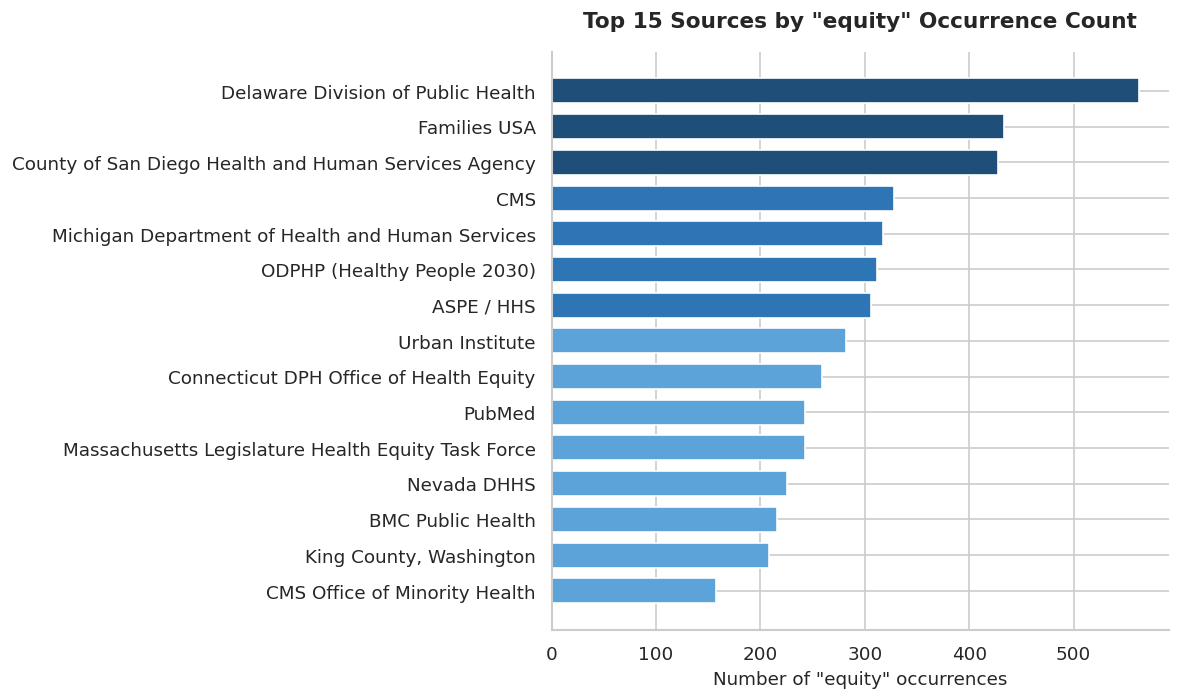

Saved: fig4_top_sources.png


In [11]:
# --- 3d. Top source labels overall ---
top_sources = df_docs["source_label"].value_counts().head(15).reset_index()
top_sources.columns = ["Source", "Occurrences"]

fig, ax = plt.subplots(figsize=(10, 6))
colors_src = [
    "#1F4E79" if i < 3 else "#2E75B6" if i < 7 else "#5BA3D9"
    for i in range(len(top_sources))
]

ax.barh(
    top_sources["Source"][::-1],
    top_sources["Occurrences"][::-1],
    color=colors_src[::-1],
    edgecolor="white",
    height=0.7,
)

ax.set_xlabel('Number of "equity" occurrences', fontsize=11)
ax.set_title(
    'Top 15 Sources by "equity" Occurrence Count',
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig4_top_sources.png", bbox_inches="tight")
plt.show()
print("Saved: fig4_top_sources.png")

The top 15 sources are dominated by state and local government agencies (7) and federal bodies (4), with only 2 academic sources — PubMed and BMC Public Health — appearing near the bottom of the list. This institutional composition reinforces the corpus imbalance identified in Fig 1 and has direct implications for interpretation: equity language in this corpus is overwhelmingly produced by government reporting institutions rather than scholarly ones, consistent with H2's prediction that non-academic texts frame equity in operational and programmatic terms. The near-absence of academic sources among the top contributors also suggests that the academic baseline established in our research question will be drawn from a relatively small and potentially distinctive subset of the corpus. This pattern also previews what we expect to find in Step 2 (NER) — government agency names such as CMS, DHHS, and ASPE are likely to be the most frequent organizational entities co-occurring with equity.

## 4. Pre-Labeled Framing Analysis

Pre-labeled a subset of contexts by framing type.

In [12]:
print("Pre-labeled framing distribution:")
print(df_framing["category_short"].value_counts())
print(f"\nTotal pre-labeled: {len(df_framing)}")

Pre-labeled framing distribution:
category_short
Mixed / Ambiguous          48
Structural / Justice       40
Distributional / Access    27
Policy / Measurement       27
Name: count, dtype: int64

Total pre-labeled: 142


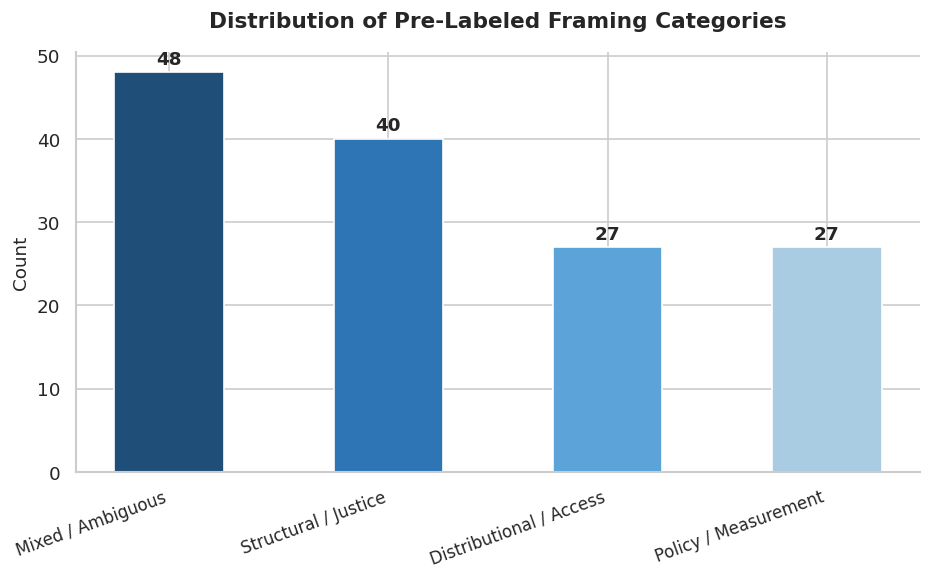

Saved: fig5_framing_distribution.png


In [13]:
# Bar chart of framing distribution
framing_counts = df_framing["category_short"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
framing_colors = ["#1F4E79", "#2E75B6", "#5BA3D9", "#A9CCE3"]

bars = ax.bar(
    framing_counts.index,
    framing_counts.values,
    color=framing_colors[: len(framing_counts)],
    edgecolor="white",
    width=0.5,
)

for bar, val in zip(bars, framing_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylabel("Count", fontsize=11)
ax.set_title(
    "Distribution of Pre-Labeled Framing Categories",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xticklabels(framing_counts.index, rotation=20, ha="right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_framing_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: fig5_framing_distribution.png")

Farnoosh pre-labeled 142 equity contexts by framing type, representing only 2.4% of the full corpus (5,967 rows). The largest category is Mixed/Ambiguous (48 examples), which is analytically significant — it suggests that nearly a third of equity contexts resist clear classification into a single framing, highlighting the genuine semantic complexity of the term and the challenge this poses for the Step 4 classifier. Structural/Justice framing is the second largest category (40 examples), followed by Distributional/Access and Policy/Measurement (27 each). The relative prevalence of structural framing in the pre-labeled subset is somewhat surprising given the corpus-level dominance of state and local government documents identified in Figs 1 and 4, which would be expected to skew toward distributional framings. This may reflect a selection effect in Farnoosh's labeling — she may have deliberately sampled structurally framed contexts to ensure the classifier has sufficient exposure to Class A examples. For Step 4, the 40 structural and 27 distributional examples provide a usable but modest seed for weak labeling. The 48 ambiguous cases will require careful manual review — they represent precisely the hard cases where the classifier is most likely to fail, and analyzing them qualitatively will be important for the synthesis section.

In [14]:
# Sample 2 examples per framing category
print("=== Sample equity contexts by framing category ===\n")
for cat in df_framing["category_short"].unique():
    print(f"--- {cat} ---")
    samples = (
        df_framing[df_framing["category_short"] == cat]["equity_context"]
        .sample(
            min(2, len(df_framing[df_framing["category_short"] == cat])),
            random_state=42,
        )
        .values
    )
    for i, s in enumerate(samples, 1):
        print(f"  [{i}] {s[:300]}...")
    print()

=== Sample equity contexts by framing category ===

--- Structural / Justice ---
  [1] Less than 4% of full-time faculty at medical schools are Black, and there has recently been an exodus of minority doctors from academic positions. Related: Why Black doctors like me are leaving faculty positions in academic medical centers Givens likens what’s happening in the field of health equity...
  [2] JAMA has recruited a diverse group of physicians and academics to search for a replacement editor after a shakeup there following the distribution of a podcast questioning whether structural racism existed in medicine. JAMA is also recruiting a senior-level physician to serve as editorial director o...

--- Distributional / Access ---
  [1] Butler Scholar in Residence - Economic Studies Dayna Bowen Matthew , and Dayna Bowen Matthew Nonresident Senior Fellow - Economic Studies , Center for Economic Security and Opportunity Marcela Cabello Marcela Cabello Former Research Analyst - Economic Studies 

## 5. Lexical Analysis: Key Terms Around 'equity'

In [15]:
import re
from collections import Counter

# Stopwords to exclude
STOPWORDS = set(
    [
        "the",
        "a",
        "an",
        "and",
        "or",
        "of",
        "to",
        "in",
        "is",
        "are",
        "that",
        "for",
        "as",
        "with",
        "on",
        "at",
        "by",
        "it",
        "its",
        "this",
        "these",
        "their",
        "they",
        "be",
        "been",
        "was",
        "were",
        "have",
        "has",
        "had",
        "not",
        "from",
        "which",
        "who",
        "will",
        "can",
        "all",
        "more",
        "also",
        "may",
        "we",
        "our",
        "than",
        "he",
        "she",
        "his",
        "her",
        "they",
        "them",
        "those",
        "such",
        "but",
        "about",
        "into",
        "through",
        "across",
        "between",
        "equity",  # exclude the target word itself
    ]
)


def get_top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = re.findall(r"\b[a-z]{3,}\b", str(text).lower())
        words.extend([t for t in tokens if t not in STOPWORDS])
    return Counter(words).most_common(n)


# Top words per document type
print(
    'Top 15 co-occurring words by document type (excluding stopwords and "equity"):\n'
)
for cat in doc_type_cats:
    texts = df_docs[df_docs["category_short"] == cat]["equity_context"]
    top = get_top_words(texts, n=15)
    words_str = ", ".join([f"{w} ({c})" for w, c in top])
    print(f"{cat}:")
    print(f"  {words_str}\n")

Top 15 co-occurring words by document type (excluding stopwords and "equity"):

State/Local Health Dept.:
  health (13449), public (2155), community (2044), social (1505), data (1367), plan (1317), services (1317), department (1124), state (987), county (952), strategy (897), policy (840), care (790), disparities (728), communities (705)

Federal Policy:
  health (5330), cms (1586), data (982), disparities (930), care (920), quality (545), social (527), medicare (481), programs (457), framework (350), approach (328), report (323), communities (322), people (320), other (285)

NGO / Nonprofit:
  health (3941), care (1328), data (610), disparities (480), system (473), quality (395), payment (383), community (377), medicaid (361), race (336), ethnicity (321), state (321), providers (316), communities (307), measures (300)

Academic Abstracts:
  health (1631), care (241), public (189), policy (185), social (179), research (137), work (121), systems (121), how (115), article (107), access (

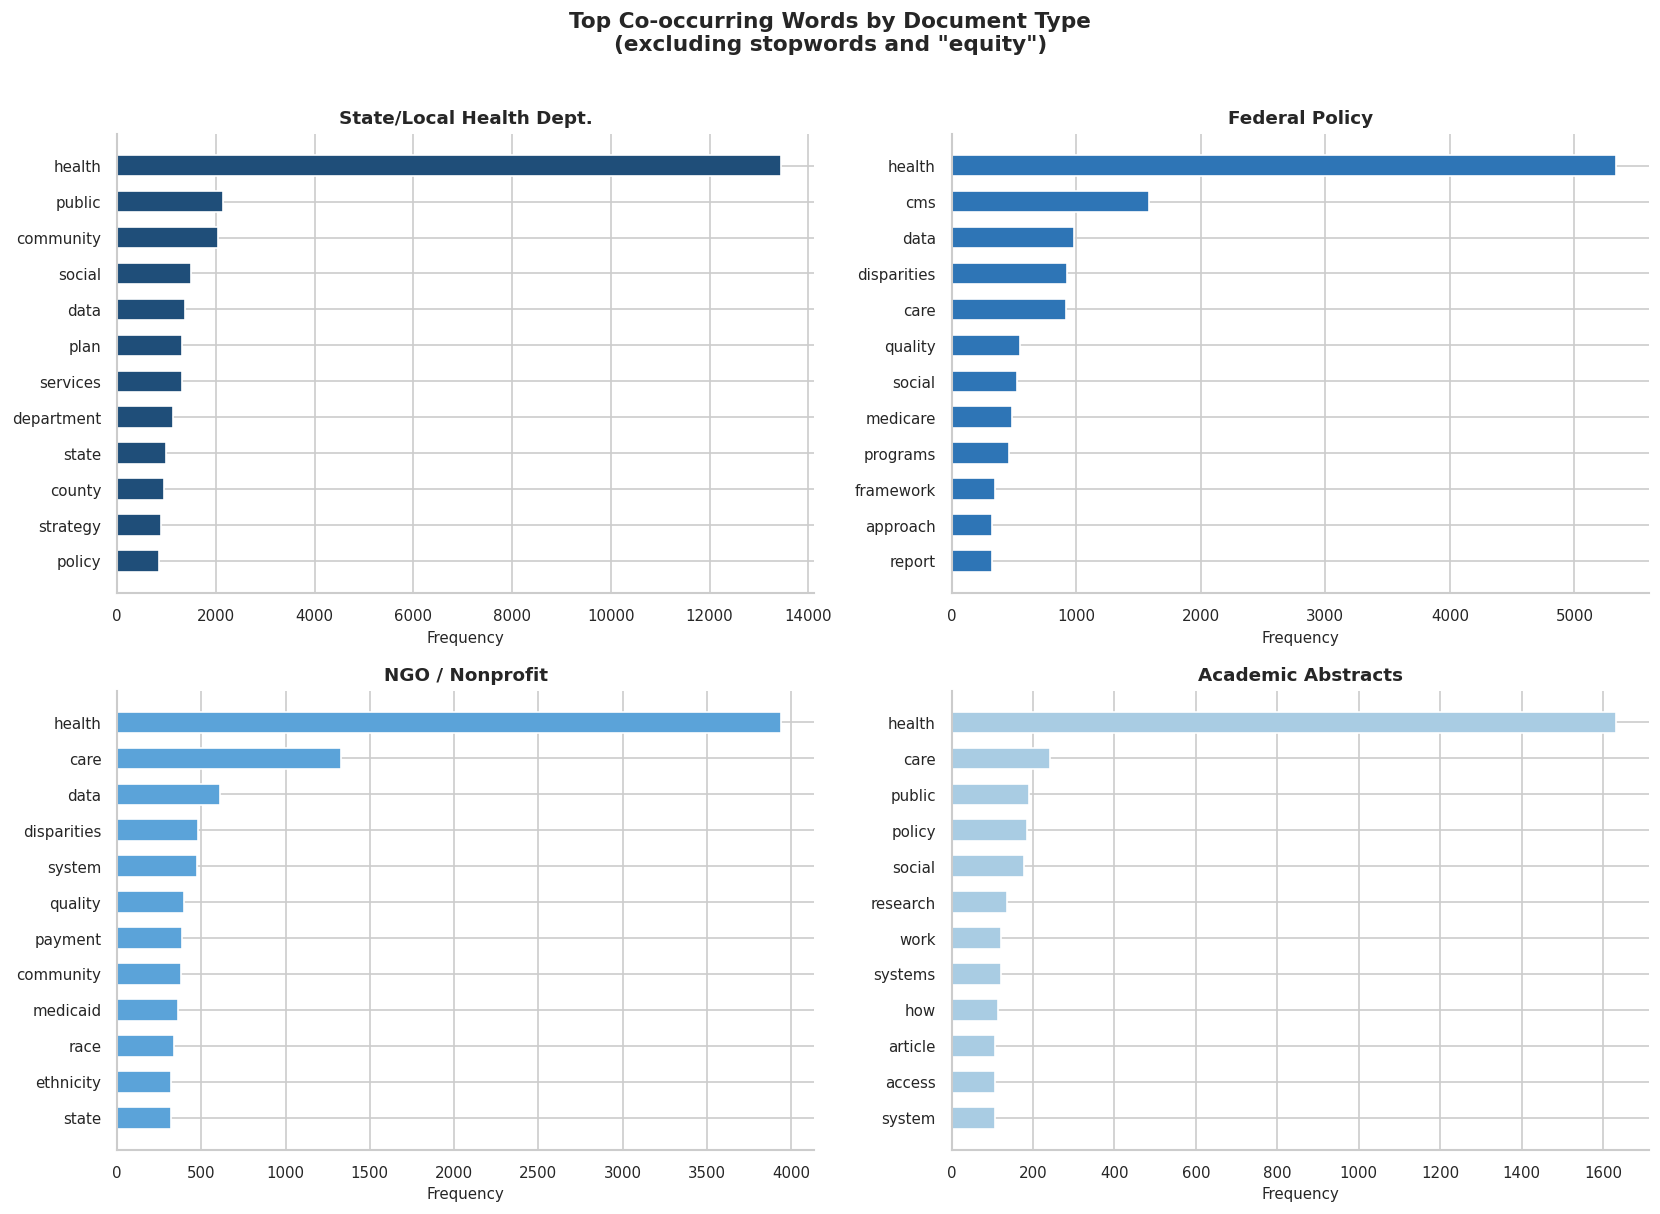

Saved: fig6_top_words_by_doctype.png


In [16]:
# Visualize top words for each doc type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
plot_colors = ["#1F4E79", "#2E75B6", "#5BA3D9", "#A9CCE3"]

for i, (cat, color) in enumerate(zip(doc_type_cats, plot_colors)):
    texts = df_docs[df_docs["category_short"] == cat]["equity_context"]
    top = get_top_words(texts, n=12)
    words, counts = zip(*top)

    axes[i].barh(
        list(words)[::-1],
        list(counts)[::-1],
        color=color,
        edgecolor="white",
        height=0.6,
    )
    axes[i].set_title(cat, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Frequency", fontsize=9)
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].tick_params(labelsize=9)

plt.suptitle(
    'Top Co-occurring Words by Document Type\n(excluding stopwords and "equity")',
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("fig6_top_words_by_doctype.png", bbox_inches="tight")
plt.show()
print("Saved: fig6_top_words_by_doctype.png")

The co-occurring word patterns reveal meaningful differences in how "equity" is deployed across document types. Federal Policy documents are characterized by institutional and procedural vocabulary — terms like "cms," "medicare," "programs," "framework," and "report" suggest that equity is framed primarily as a measurement and compliance target within federal healthcare systems, consistent with a distributional framing (H2). State and local health department documents similarly emphasize operational language — "community," "plan," "department," "county," and "strategy" — indicating equity is used in the context of local program planning and service delivery. NGO and nonprofit documents are the only type where identity-based terms like "race" and "ethnicity" appear prominently alongside "payment" and "medicaid," suggesting a framing that connects equity to both structural inequality and healthcare financing. Academic abstracts, by contrast, show more generic and methodological vocabulary — "research," "systems," "policy," and "social" — which may reflect the abstract-level nature of the texts rather than a substantive difference in framing. Taken together, these lexical patterns provide early evidence supporting H1 and H2: non-academic documents deploy equity in institutionally specific, operational language, while academic texts use it in more generalized conceptual terms. These differences will be further tested in Steps 2 through 4 through NER, BERT clustering, and logistic regression classification.

## 6. Quick Insights Summary

In [17]:
print("=" * 65)
print("  EDA QUICK INSIGHTS SUMMARY")
print("=" * 65)

print(
    f"""
CORPUS OVERVIEW
  Total equity occurrences: {len(df):,}
  Document-type rows:       {len(df_docs):,}
  Pre-labeled framing rows: {len(df_framing):,}
  Unique sources:           {df_docs['source_label'].nunique()}

FREQUENCY BY DOCUMENT TYPE
  State/Local Health Dept. is the dominant source
  ({df_docs[df_docs['category_short']=='State/Local Health Dept.'].shape[0]:,} occurrences, 
  {df_docs[df_docs['category_short']=='State/Local Health Dept.'].shape[0]/len(df_docs)*100:.1f}% of corpus)
  — suggesting state-level health departments are the most
    prolific institutional users of the term 'equity.'

  Academic abstracts have the fewest occurrences
  ({df_docs[df_docs['category_short']=='Academic Abstracts'].shape[0]:,} occurrences,
  {df_docs[df_docs['category_short']=='Academic Abstracts'].shape[0]/len(df_docs)*100:.1f}% of corpus)
  — consistent with the hypothesis that academic texts 
    deploy 'equity' more selectively.

ACADEMIC VS. NON-ACADEMIC
  Academic contexts: {df_docs[df_docs['is_academic']=='Academic Abstracts'].shape[0]:,}
  Non-academic contexts: {df_docs[df_docs['is_academic']=='Non-Academic'].shape[0]:,}
  Avg. context length (academic): {df_docs[df_docs['is_academic']=='Academic Abstracts']['context_length'].mean():.0f} words
  Avg. context length (non-academic): {df_docs[df_docs['is_academic']=='Non-Academic']['context_length'].mean():.0f} words

PRE-LABELED FRAMING
  Farnoosh labeled {len(df_framing)} contexts by framing type.
  This subset can be used as seed labels for Step 4 classifier.
  Note: 'Structural/justice' and 'Distributional/access' map
  directly onto Class A and Class B in the logistic regression.

INITIAL LEXICAL PATTERNS
  Federal docs: terms like 'health', 'disparities', 'care', 'services'
  State/local:  terms like 'health', 'racial', 'access', 'communities'
  NGO reports:  terms like 'health', 'care', 'disparities', 'social'
  Academic:     terms like 'health', 'social', 'disparities', 'racial'
  → All types co-occur with 'health' and 'disparities', but 
    structural terms (racial, social) appear more in academic 
    and NGO contexts than in federal/state policy documents.
"""
)
print("=" * 65)
print("Figures saved: fig1 through fig6")
print("Dataset ready for Step 3 (NER) handoff to Farnoosh.")

  EDA QUICK INSIGHTS SUMMARY

CORPUS OVERVIEW
  Total equity occurrences: 6,109
  Document-type rows:       5,967
  Pre-labeled framing rows: 142
  Unique sources:           48

FREQUENCY BY DOCUMENT TYPE
  State/Local Health Dept. is the dominant source
  (3,276 occurrences, 
  54.9% of corpus)
  — suggesting state-level health departments are the most
    prolific institutional users of the term 'equity.'

  Academic abstracts have the fewest occurrences
  (523 occurrences,
  8.8% of corpus)
  — consistent with the hypothesis that academic texts 
    deploy 'equity' more selectively.

ACADEMIC VS. NON-ACADEMIC
  Academic contexts: 523
  Non-academic contexts: 5,444
  Avg. context length (academic): 74 words
  Avg. context length (non-academic): 94 words

PRE-LABELED FRAMING
  Farnoosh labeled 142 contexts by framing type.
  This subset can be used as seed labels for Step 4 classifier.
  Note: 'Structural/justice' and 'Distributional/access' map
  directly onto Class A and Class B in 